In [1]:
import numpy as np
import json
import torch
from torchsummary import summary
from tqdm import tqdm
from pathlib import Path

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6


In [3]:
from src.models.parallelEncoder_model import parallelEncoder_model
from src.models.hugeKernelEncoder_model import hugeKernelEncoder_model
from src.models.deepEncoder_model import deepEncoder_model
from src.models.UNetLike_model import UNetLike_model

from src.utils.metrics import AverageMeter, CombinedLoss, DiceLoss, dice_coefficient, iou_score, pixel_accuracy

Пути к каталогам.

In [4]:
config_dir = Path("./src/config/")
model_name = 'UNetLike-model'

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

model_config_path = config_dir / f"{model_name}-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

dataset_config_path = config_dir / f"{model_config['dataset_name']}-config.json"
assert dataset_config_path.exists(), f"Config not found: {dataset_config_path}"
with open(dataset_config_path, "r") as f:
    dataset_config = json.load(f)
    
data_path = Path(general_config['data_dir']) / dataset_config['dataset_name']
checkpoints_dir = Path(general_config['checkpoints_dir'])

In [5]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

# Тест архитектуры

In [6]:
mdl_input_size = model_config['input_size']

if model_name == 'parallelEncoder-model':
    model_type = parallelEncoder_model
elif model_name == 'hugeKernelEncoder-model':
    model_type = hugeKernelEncoder_model
elif model_name == 'deepEncoder-model':
    model_type = deepEncoder_model
elif model_name == 'UNetLike-model':
    model_type = UNetLike_model

model = model_type(
    in_channels = mdl_input_size[0],
    out_channels = 4,
    features = model_config['feature_list']
    )

model = model.to(device)
model.eval()

test_input = torch.randn(1, *mdl_input_size).to(device)
test_output = model(test_input)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size}")
print(f"  Input:  {test_input.shape}")
print(f"  Output: {test_output.shape}")
summary(model, tuple(mdl_input_size))

Encoder features by level: [32, 64]


RuntimeError: Given groups=1, weight of size [32, 3, 3], expected input[1, 32, 512] to have 3 channels, but got 32 channels instead

In [ ]:
test_output

NameError: name 'test_output' is not defined

## dataloader

In [7]:
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [8]:
from src.dataloaders.ZerosPolesDataset import TransformsConfig, ZerosPolesDataset
from torch.utils.data import DataLoader
# Setting seeds.
def worker_init_fn(worker_id):
    np.random.seed(torch.initial_seed() % 2 ** 32)
    
train_transforms = TransformsConfig(
    #crop_ratio=[1.0, 1.0],
    time_delay=[0.0, 1e-9],
    noise_level=[5e-3, 30e-3],
    noise_reduce=2,
    #gain=[0.9, 1.1]
)
val_transforms = None

train_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'train',
        mask_halfwindow=model_config["mask_halfwindow"],
        transforms=train_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=True,
    num_workers=0,#model_config["workers"],
    worker_init_fn=worker_init_fn,
    pin_memory=True)

val_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'val',
        mask_halfwindow=model_config["mask_halfwindow"],
        transforms=val_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=False,
    num_workers=model_config["workers"],
    pin_memory=True)

In [9]:
inputs, masks, _ = next(iter(val_loader))

In [10]:
inputs.shape

torch.Size([1440, 3, 512])

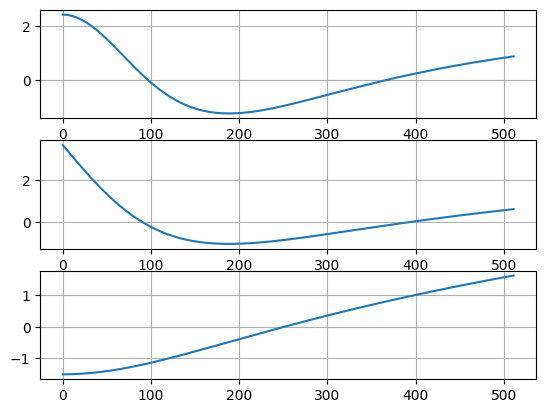

In [49]:
import matplotlib.pyplot as plt
import torch.nn as nn
instance_norm = nn.InstanceNorm1d(
    num_features=3, 
    affine=True, # Allows model to learn optimal scale/shift.
    eps=1e-9
)

data_tensor = instance_norm((inputs[1330])).detach().numpy()
#data_tensor = inputs[1330].detach().numpy()

fig, axes = plt.subplots(len(data_tensor), 1)
#plt.plot(data_tensor)

for ax, data in zip(axes, data_tensor):
    ax.plot(data)
    ax.grid()

plt.show()

In [50]:
np.std(data_tensor, axis=1)

array([0.9891122 , 0.9999931 , 0.99999994], dtype=float32)

In [33]:
data_tensor.shape

(512,)

In [ ]:
checkpoints_file = checkpoints_dir / f"best_{model_name}.pth"
assert checkpoints_file.exists(), f"Checkpoints not found: {checkpoints_file}"

from src.models.model_utilizer import load_net

model, epoch, _, _ = load_net(
                net=model,
                checkpoints_file=checkpoints_file,
                device=device
        )

model.eval()

Restoring checkpoint:  checkpoints\best_base-model.pth


_base_model(
  (input_norm): InstanceNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (encoder1_1): Sequential(
    (0): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv1d(2, 8, kernel_size=(32,), stride=(2,), padding=(15,))
    (2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Conv1d(8, 8, kernel_size=(16,), stride=(2,), padding=(7,))
  )
  (encoder1_2): Sequential(
    (0): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): Conv1d(8, 16, kernel_size=(16,), stride=(2,), padding=(7,))
    (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv1d(16, 16, kernel_size=(8,), stride=(2,), padding=(3,))
  )
  (encoder1_3): Sequential(
    (0): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

d:\git\ITMO\frequency-response-encoder\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


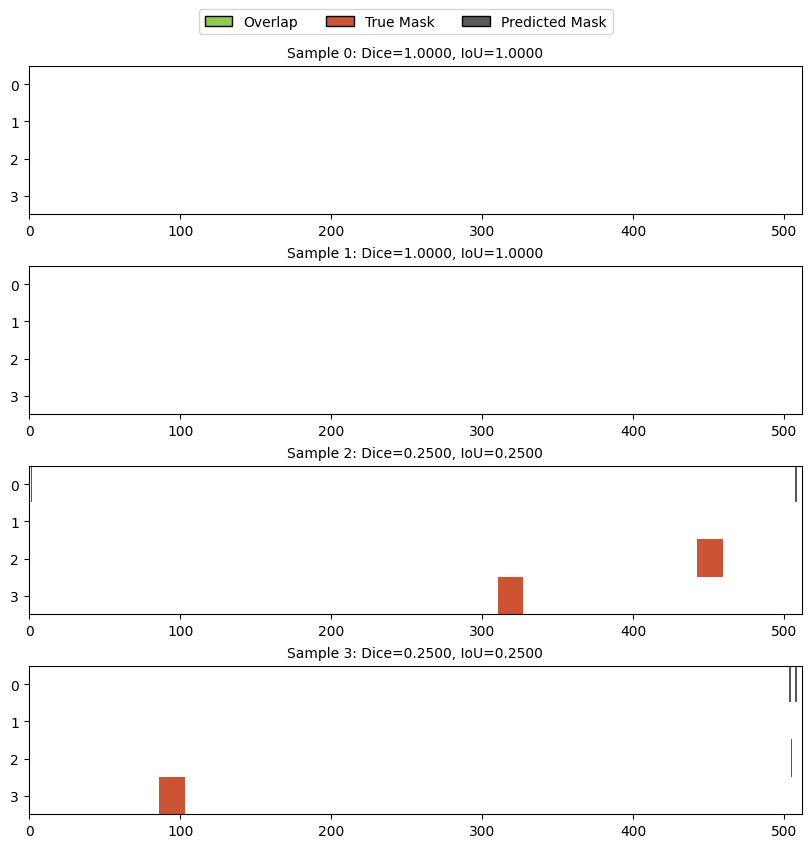

In [ ]:
from src.utils.debug_functions import visualize_predictions

num_samples = 4
inputs, masks, _ = next(iter(val_loader))

# Get random indices from the batch.
batch_size = inputs.shape[0]
random_indices = torch.randperm(batch_size)[:num_samples]

inputs = inputs[random_indices]
masks = masks[random_indices]

with torch.no_grad():
        logits = model(inputs.to(device))

visualize_predictions(
        logits_all=logits.detach(),
        masks_all=masks.detach(),
        dice_func=dice_coefficient,
        iou_func=iou_score,
        save_path=None,
        threshold=0.5
        )

# Статистики тренировочного датасета

In [ ]:
# 1. Initialize accumulators (use float64 for numerical stability)
channel_sum = None
channel_sum_sq = None
total_samples = 0  # Total number of scalar values per channel

# 2. Iterate over dataset
with torch.no_grad():
    for data_tuple in tqdm(val_loader, desc="Calculating Stats"):
        inputs = data_tuple[0].to(device)
        
        inputs = inputs.float()
        B, C, L = inputs.shape  # [Batch, Channels, Length]
        
        # Initialize on first batch (handles dynamic channel count)
        if channel_sum is None:
            channel_sum = torch.zeros(C, dtype=torch.float64, device=device)
            channel_sum_sq = torch.zeros(C, dtype=torch.float64, device=device)
        
        # 3. Accumulate sum and sum of squares per channel
        # Sum over Batch (0) and Length (2), keep Channel (1)
        channel_sum += inputs.sum(dim=(0, 2)).double()
        channel_sum_sq += (inputs ** 2).sum(dim=(0, 2)).double()
        
        # Count total samples per channel: Batch * Length
        total_samples += B * L

# 4. Compute Final Mean and Std
mean = channel_sum / total_samples
# Variance = E[X²] - (E[X])²
var = (channel_sum_sq / total_samples) - (mean ** 2)

mean = mean.cpu()
std = torch.sqrt(var).cpu()

print(f"Mean: {mean.numpy()}")
print(f"Std:  {std.numpy()}")

Calculating Stats: 100%|██████████| 20/20 [00:17<00:00,  1.15it/s]

Mean: [73.78254582 56.64125688]
Std:  [1931.63342489 1482.18908522]


## Run 1:
- Mean: [ 984.91466768 2397.26128974]
- Std:  [ 55818.49198814 218841.79374928]

## Run 2:
- Mean: [1001.5774273 2397.346644 ]
- Std:  [ 57678.93105483 218281.70283202]

## Run 3:
- Mean: [1014.77855625 2394.29139941]
- Std:  [ 59264.07932032 217862.15627679]

In [ ]:
with torch.no_grad():
    
    inputs, masks, _ = next(iter(val_loader))
    inputs, masks = inputs.to(device), masks.to(device)
    
    outputs = model(inputs)
        
    print(dice_coefficient(outputs.detach(), masks.detach()))
    print(iou_score(outputs.detach(), masks.detach()))
    
    '''
    for data_tuple in tqdm(val_loader, desc="Val"):
        
        inputs, masks = data_tuple[0].to(device), data_tuple[1].to(device)
        
        outputs = model(inputs)
        
        print(dice_coefficient(outputs.detach(), masks.detach()))
        print(iou_score(outputs.detach(), masks.detach()))
    '''

0.528163731098175
0.527982234954834
